<h1 style="text-align: center;">Individual Assignment 1 - Part 1</h1>
<h3 style="text-align: center;">Case Studies for Data Science - semester 2 2026</h3> 
<h4 style="text-align: center;"> Rose Munro s4054011 </h4>


In [1]:
#TODO: Load Libraries
import pandas as pd
from pathlib import Path 
import re
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet #as we have a few metric from each category (income, education etc) predictors are highly correlated
from sklearn.preprocessing import StandardScaler #Elastic net sensitive to scale

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold


In [2]:
#Using 2021 Census data as most current data with AEDC data match
Path.cwd()

WindowsPath('c:/Users/Rose3/OneDrive/Documents/2026 - semester 2/Case Studies for Data Science/Individual A1/Ind A1 Repo')

### 1. Data Loading


#### Load AEDC Data (Target)

In [3]:
!jupyter --version


Selected Jupyter core packages...
IPython          : 9.16.1
ipykernel        : 7.3.0
ipywidgets       : not installed
jupyter_client   : 8.9.1
jupyter_core     : 5.9.1
jupyter_server   : 2.20.0
jupyterlab       : 4.6.3
nbclient         : 0.11.0
nbconvert        : 7.17.1
nbformat         : 5.11.0
notebook         : 7.6.2
qtconsole        : not installed
traitlets        : 5.16.1


In [4]:
aedc_target = pd.read_excel("data\\aedc_target.xlsx",
              sheet_name = "Target_sorted",
              dtype={"Code": str},
              na_values="*")

In [5]:
aedc_target.info()

<class 'pandas.DataFrame'>
RangeIndex: 2210 entries, 0 to 2209
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Code             2210 non-null   str    
 1   Name             2210 non-null   str    
 2   #Valid_Scores    2210 non-null   int64  
 3   #Dev_Vulnerable  2138 non-null   float64
 4   %Dev_Vulnerable  2138 non-null   float64
dtypes: float64(2), int64(1), str(2)
memory usage: 86.5 KB


In [6]:
# aedc_target.tail(10)
aedc_target.tail(10)

,Code,Name,#Valid_Scores,#Dev_Vulnerable,%Dev_Vulnerable
2200,801101135,Coombs,70,7.0,10.000000
2201,801101136,Denman Prospect,53,11.0,20.754717
2202,801101137,Molonglo,0,NaN,NaN
2203,801101139,Wright,53,6.0,11.320755
2204,801101145,Molonglo - East,0,NaN,NaN
2205,801101146,Whitlam,0,NaN,NaN
2206,801111140,ACT - South West,8,NaN,NaN
2207,801111141,Namadgi,0,NaN,NaN
2208,901031003,Jervis Bay,5,NaN,NaN
2209,901041004,Norfolk Island,24,3.0,12.500000


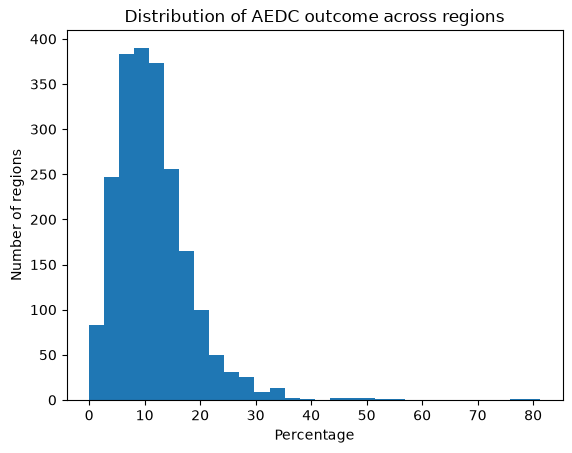

In [7]:
aedc_target["%Dev_Vulnerable"].plot.hist(bins=30)
plt.xlabel("Percentage")
plt.ylabel("Number of regions")
plt.title("Distribution of AEDC outcome across regions")
plt.show()

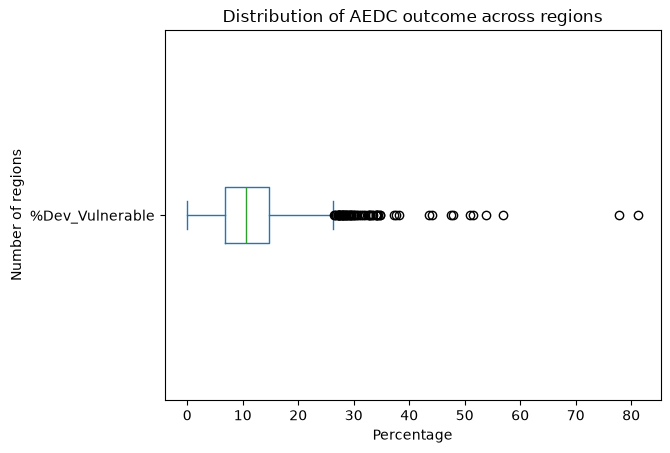

In [8]:
aedc_target["%Dev_Vulnerable"].plot.box(vert=False)
plt.xlabel("Percentage")
plt.ylabel("Number of regions")
plt.title("Distribution of AEDC outcome across regions")
plt.show()

---

#### Load Australian Bureau of Statistics Data


In [9]:
ABS_census_features = pd.read_excel("data\\ABS_census_features.xlsx",
              sheet_name = "Features",
              dtype={"Code": str})

In [10]:
ABS_census_features.head()

,Code,Median_tot_hhd_inc_weekly,Median_tot_prsnl_inc_weekly,Median_mortgage_repay_monthly,Median_rent_weekly,Average_num_psns_per_bedroom,Average_household_size,High_yr_schl_comp_Yr_12_eq_P,High_yr_schl_comp_Yr_10_eq_P,P_Tot_Emp_Tot,P_Tot_Unemp_Tot,Tot_Indigenous_%
0,101021007,1429,760,1732,330,0.8,2.2,1832,897,2013,68,0.024637
1,101021008,1989,975,1950,350,0.8,2.6,3569,1567,4315,198,0.072443
2,101021009,1703,996,1700,330,0.9,2.1,5739,1793,6247,270,0.034738
3,101021010,1796,1104,1700,310,0.9,2.1,2749,729,2922,108,0.033235
4,101021012,3014,1357,2300,430,0.8,2.9,6681,1748,7398,170,0.027228


In [11]:
ABS_census_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 2472 entries, 0 to 2471
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Code                           2472 non-null   str    
 1   Median_tot_hhd_inc_weekly      2472 non-null   int64  
 2   Median_tot_prsnl_inc_weekly    2472 non-null   int64  
 3   Median_mortgage_repay_monthly  2472 non-null   int64  
 4   Median_rent_weekly             2472 non-null   int64  
 5   Average_num_psns_per_bedroom   2472 non-null   float64
 6   Average_household_size         2472 non-null   float64
 7   High_yr_schl_comp_Yr_12_eq_P   2472 non-null   int64  
 8   High_yr_schl_comp_Yr_10_eq_P   2472 non-null   int64  
 9   P_Tot_Emp_Tot                  2472 non-null   int64  
 10  P_Tot_Unemp_Tot                2472 non-null   int64  
 11  Tot_Indigenous_%               2472 non-null   float64
dtypes: float64(3), int64(8), str(1)
memory usage: 231.9 KB


---

#### 2. Data preprocessing / cleaning 

handle missing values, duplicates, noise, inconsistent formatting, outliers

#### Merge Target and features (join on SA2 code)

In [12]:
df = pd.merge(ABS_census_features, aedc_target, how="inner", on="Code")

In [13]:
df.head()

,Code,Median_tot_hhd_inc_weekly,Median_tot_prsnl_inc_weekly,Median_mortgage_repay_monthly,Median_rent_weekly,Average_num_psns_per_bedroom,Average_household_size,High_yr_schl_comp_Yr_12_eq_P,High_yr_schl_comp_Yr_10_eq_P,P_Tot_Emp_Tot,P_Tot_Unemp_Tot,Tot_Indigenous_%,Name,#Valid_Scores,#Dev_Vulnerable,%Dev_Vulnerable
0,101021007,1429,760,1732,330,0.8,2.2,1832,897,2013,68,0.024637,Braidwood,48,2.0,4.166667
1,101021008,1989,975,1950,350,0.8,2.6,3569,1567,4315,198,0.072443,Karabar,98,17.0,17.346939
2,101021009,1703,996,1700,330,0.9,2.1,5739,1793,6247,270,0.034738,Queanbeyan,125,17.0,13.600000
3,101021010,1796,1104,1700,310,0.9,2.1,2749,729,2922,108,0.033235,Queanbeyan - East,62,7.0,11.290323
4,101021012,3014,1357,2300,430,0.8,2.9,6681,1748,7398,170,0.027228,Queanbeyan West - Jerrabomberra,195,15.0,7.692308


In [14]:
#Remove unnecessary target columns
df.drop(columns=["#Valid_Scores", "#Dev_Vulnerable"], inplace=True)


### 3.	Exploratory data analysis (EDA) 

---

### 4. Feature Engineering

In [16]:
df['Labour_force_total'] = df['P_Tot_Emp_Tot'] + df['P_Tot_Unemp_Tot']
df['Unemployment rate'] = df['P_Tot_Unemp_Tot'] / df['Labour_force_total']

#### Scaling


---

### 5. Train/validation/test split 
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html

In [17]:
X, y = df.drop(columns=["Code","Name", "%Dev_Vulnerable"]), df["%Dev_Vulnerable"]

In [18]:
X.head()

,Median_tot_hhd_inc_weekly,Median_tot_prsnl_inc_weekly,Median_mortgage_repay_monthly,Median_rent_weekly,Average_num_psns_per_bedroom,Average_household_size,High_yr_schl_comp_Yr_12_eq_P,High_yr_schl_comp_Yr_10_eq_P,P_Tot_Emp_Tot,P_Tot_Unemp_Tot,Tot_Indigenous_%,Labour_force_total,Unemployment rate
0,1429,760,1732,330,0.8,2.2,1832,897,2013,68,0.024637,2081,0.032677
1,1989,975,1950,350,0.8,2.6,3569,1567,4315,198,0.072443,4513,0.043873
2,1703,996,1700,330,0.9,2.1,5739,1793,6247,270,0.034738,6517,0.041430
3,1796,1104,1700,310,0.9,2.1,2749,729,2922,108,0.033235,3030,0.035644
4,3014,1357,2300,430,0.8,2.9,6681,1748,7398,170,0.027228,7568,0.022463


In [19]:
y.head()

0     4.166667
1    17.346939
2    13.600000
3    11.290323
4     7.692308
Name: %Dev_Vulnerable, dtype: float64

In [20]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf.get_n_splits()

5

In [21]:
for i, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {i+1}:")
    print(f"Train indices: {train_index}")
    print(f"Test indices: {test_index}")
    print()

Fold 1:
Train indices: [   0    1    2 ... 2207 2208 2209]
Test indices: [  13   23   29   44   48   49   51   56   59   63   65   67   69   70
   71   73   76   96   99  100  105  109  111  115  120  121  124  128
  134  135  163  168  173  178  179  184  185  188  192  196  198  203
  205  210  211  212  218  219  220  230  231  233  237  239  240  247
  251  254  259  275  281  282  289  290  296  297  298  299  303  306
  307  308  316  321  324  332  342  350  351  353  354  360  361  367
  368  382  383  387  406  408  409  410  414  416  420  422  426  427
  430  432  433  435  438  445  450  471  479  480  482  485  486  494
  507  508  514  519  527  528  529  530  532  535  538  543  544  548
  554  555  561  564  582  585  588  599  601  602  605  611  613  620
  630  634  636  637  647  650  668  678  679  680  686  707  715  719
  727  736  744  752  755  759  772  781  782  785  786  788  807  808
  809  810  812  829  831  838  839  855  857  859  861  867  888  891
  89

----

### 6. Training 

In [22]:
df.columns

Index(['Code', 'Median_tot_hhd_inc_weekly', 'Median_tot_prsnl_inc_weekly',
       'Median_mortgage_repay_monthly', 'Median_rent_weekly',
       'Average_num_psns_per_bedroom', 'Average_household_size',
       'High_yr_schl_comp_Yr_12_eq_P', 'High_yr_schl_comp_Yr_10_eq_P',
       'P_Tot_Emp_Tot', 'P_Tot_Unemp_Tot', 'Tot_Indigenous_%', 'Name',
       '%Dev_Vulnerable', 'Labour_force_total', 'Unemployment rate'],
      dtype='str')

----

### 7. Evaluation

---